In [1]:
!git clone "https://github.com/schiWasTaken/YOLOv5-PyTorch.git"
%cd "YOLOv5-PyTorch"
!git checkout schi1

Cloning into 'YOLOv5-PyTorch'...
remote: Enumerating objects: 288, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 288 (delta 65), reused 52 (delta 51), pack-reused 188 (from 2)
Receiving objects: 100% (288/288), 46.36 MiB | 16.63 MiB/s, done.
Resolving deltas: 100% (136/136), done.
/content/YOLOv5-PyTorch
Branch 'schi1' set up to track remote branch 'schi1' from 'origin'.
Switched to a new branch 'schi1'


In [2]:
import os

file_id = "1ZQt1vACHTN98QJYaT2JW3kPF-wziHyPX"
os.makedirs("ckpts", exist_ok=True)
output = "ckpts/model_best.pth.tar"

!gdown --id {file_id} -O {output}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1ZQt1vACHTN98QJYaT2JW3kPF-wziHyPX
To: /content/YOLOv5-PyTorch/ckpts/model_best.pth.tar
100% 45.3M/45.3M [00:00<00:00, 153MB/s]


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="M8g3XQqHBOnUeEIk4eih")
project = rf.workspace("kuliah-rwptj").project("traffic-sign-indonesia")
version = project.version(2)
dataset = version.download("coco")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 139.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Traffic-Sign-Indonesia-2 in coco:: 100%|██████████| 3530/3530 [00:00<00:00, 5646.73it/s]


In [24]:
import torch
import yolo
from PIL import Image
from torchvision import transforms

classes = (
  "Dilarang Berhenti",
  "Dilarang Masuk",
  "Dilarang Parkir",
  "Lampu Hijau",
  "Lampu Kuning",
  "Lampu Merah",
  "Larangan Belok Kanan",
  "Larangan Belok Kiri",
  "Larangan Berjalan Terus Wajib Berhenti Sesaat",
  "Larangan Memutar Balik",
  "Peringatan Alat Pemberi Isyarat Lalu Lintas",
  "Peringatan Banyak Pejalan Kaki Menggunakan Zebra Cross",
  "Peringatan Hati-Hati",
  "Peringatan Pintu Perlintasan Kereta Api",
  "Peringatan Simpang Tiga Sisi Kiri",
  "Perintah Masuk Jalur Kiri",
  "Perintah Pilihan Memasuki Salah Satu Jalur",
  "Petunjuk Area Parkir",
  "Petunjuk Lokasi Pemberhentian Bus",
  "Petunjuk Lokasi Putar Balik",
  "Petunjuk Penyeberangan Pejalan Kaki")

model = yolo.YOLOv5(22, img_sizes=(640, 640), score_thresh=0.25)
model.eval()

YOLOv5(
  (backbone): BackboneWithFPN(
    (body): MyAwesomeLayers(
      (stem): Sequential(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): InvertedResidual(
          (conv): Sequential(
            (0): ConvNormAct(
              (conv): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (norm_layer): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            )
            (1): ConvNormAct(
              (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
              (norm_layer): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (act): SiLU()
            )
            (2): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
      )
      (stage1): Sequential(
      

In [11]:
import os
import shutil

# 🧠 Change this variable if your dataset folder name changes
dataset_name = "Traffic-Sign-Indonesia-2"
base_dir = f"/content/YOLOv5-PyTorch/{dataset_name}"

# Paths
train_old = os.path.join(base_dir, "train")
val_old = os.path.join(base_dir, "valid")
train_new = os.path.join(base_dir, "train2017")
val_new = os.path.join(base_dir, "val2017")
annotations_dir = os.path.join(base_dir, "annotations")

# --- Rename train/val folders ---
if os.path.exists(train_old):
    os.rename(train_old, train_new)
    print(f"📁 Renamed: {train_old} → {train_new}")
else:
    print(f"⚠️ Skipped: {train_old} not found")

if os.path.exists(val_old):
    os.rename(val_old, val_new)
    print(f"📁 Renamed: {val_old} → {val_new}")
else:
    print(f"⚠️ Skipped: {val_old} not found")

# --- Create annotations directory ---
os.makedirs(annotations_dir, exist_ok=True)
print(f"📂 Created annotations folder: {annotations_dir}")

# --- Copy and rename JSON files ---
train_json_src = os.path.join(train_new, "_annotations.coco.json")
val_json_src = os.path.join(val_new, "_annotations.coco.json")

train_json_dst = os.path.join(annotations_dir, "instances_train2017.json")
val_json_dst = os.path.join(annotations_dir, "instances_val2017.json")

if os.path.exists(train_json_src):
    shutil.copy2(train_json_src, train_json_dst)
    print(f"✅ Copied: {train_json_src} → {train_json_dst}")
else:
    print(f"⚠️ Missing: {train_json_src}")

if os.path.exists(val_json_src):
    shutil.copy2(val_json_src, val_json_dst)
    print(f"✅ Copied: {val_json_src} → {val_json_dst}")
else:
    print(f"⚠️ Missing: {val_json_src}")

print("\n🎉 All operations completed!")



⚠️ Skipped: /content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/train not found
⚠️ Skipped: /content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/valid not found
📂 Created annotations folder: /content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/annotations
✅ Copied: /content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/train2017/_annotations.coco.json → /content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/annotations/instances_train2017.json
✅ Copied: /content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/val2017/_annotations.coco.json → /content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/annotations/instances_val2017.json

🎉 All operations completed!


In [25]:
import os

use_cuda = False
dataset = "coco" # currently only support VOC and COCO datasets
file_root = "Traffic-Sign-Indonesia-2/train2017"
ann_file = "Traffic-Sign-Indonesia-2/train2017/_annotations.coco.json"
output_dir = "output_dir"
ckpt_path = "/content/YOLOv5-PyTorch/ckpts/yolov5s_coco-10.pth"

# create output directory
if not os.path.exists(output_dir):
    os.mkdir(output_dir)

# choose device and show GPU information
device = torch.device("cuda" if torch.cuda.is_available() and use_cuda else "cpu")
cuda = device.type == "cuda"
if cuda: yolo.get_gpu_prop(show=True)
print("\ndevice: {}".format(device))

ds = yolo.datasets(dataset, file_root, ann_file, train=True)
dl = torch.utils.data.DataLoader(ds, shuffle=True, collate_fn=yolo.collate_wrapper, pin_memory=cuda)
# DataPrefetcher behaves like PyTorch's DataLoader, but it outputs CUDA tensors
d = yolo.DataPrefetcher(dl) if cuda else dl

model.to(device)

if ckpt_path:
    checkpoint = torch.load(ckpt_path, map_location=device)
    if "ema" in checkpoint:
        model.load_state_dict(checkpoint["ema"][0])
        print(checkpoint["eval_info"])
    else:
        model.load_state_dict(checkpoint)
    del checkpoint
    if cuda: torch.cuda.empty_cache()

for p in model.parameters():
    p.requires_grad_(False)


device: cpu
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.513
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.864
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.576
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.177
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.534
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.554
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.586
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.586
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.191
 Averag

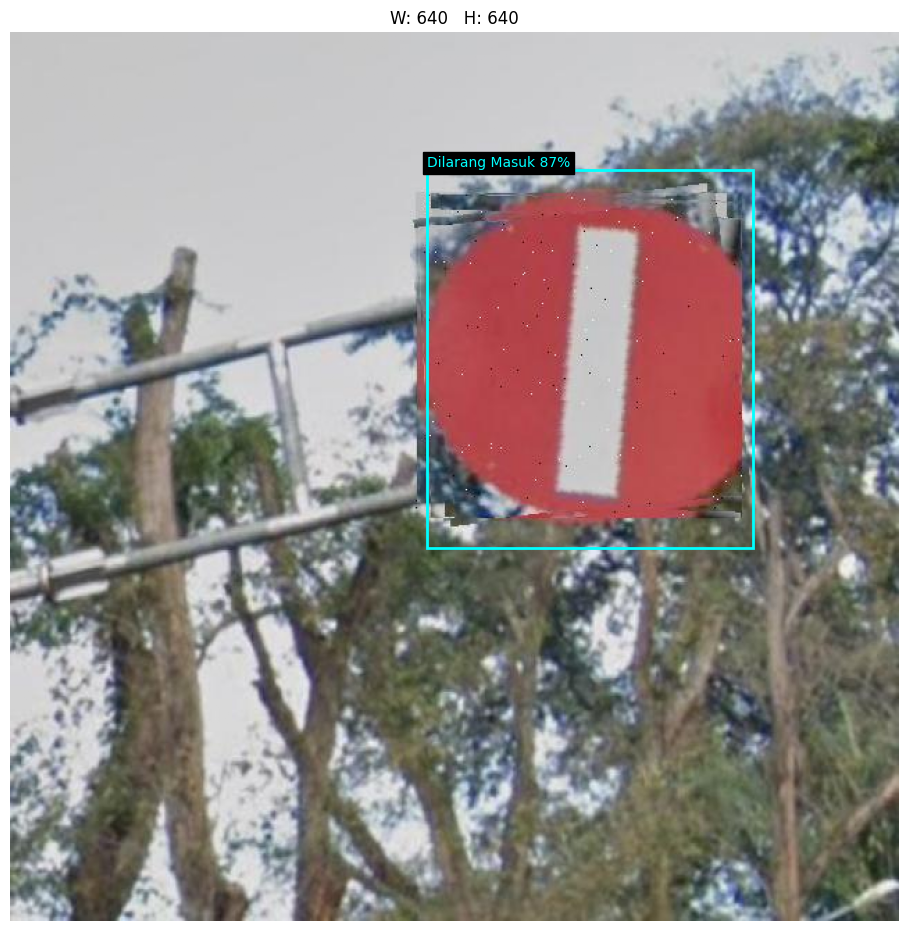

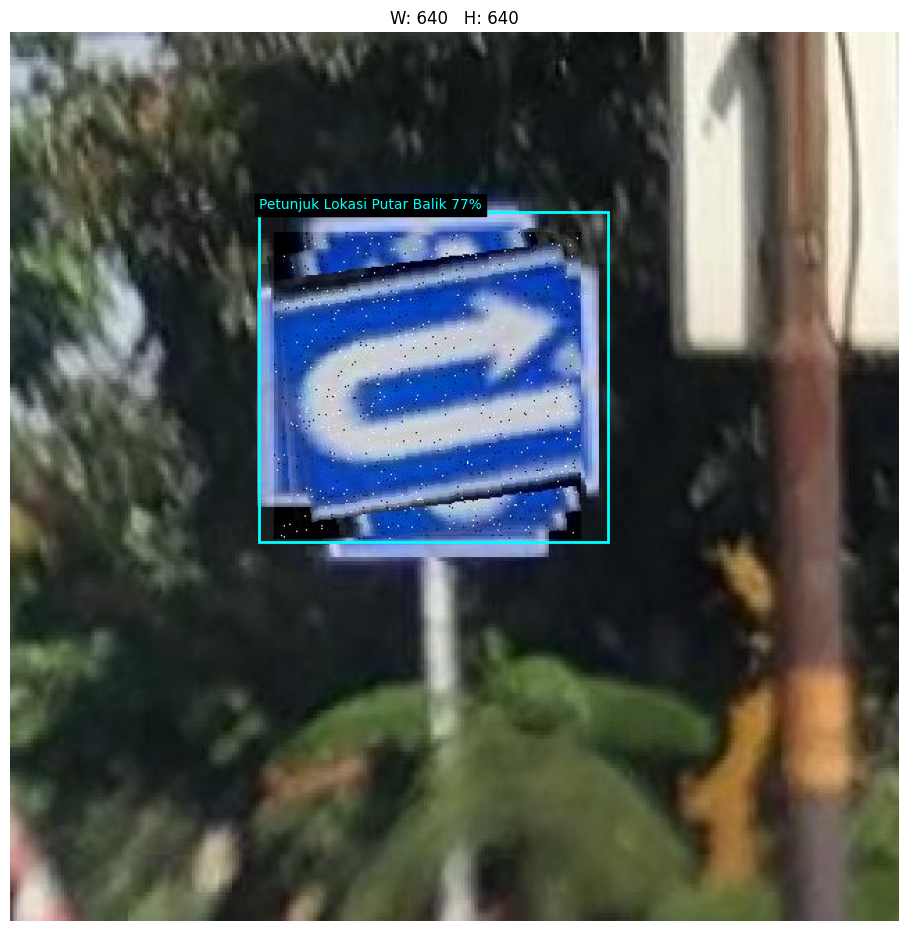

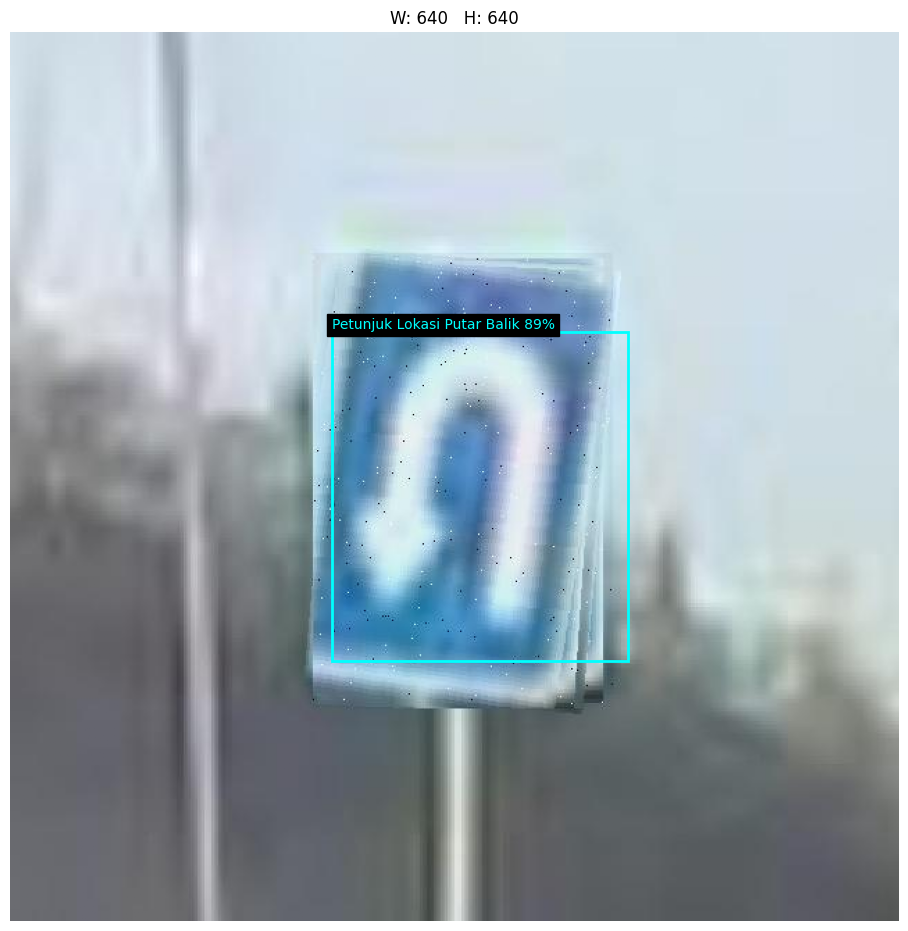

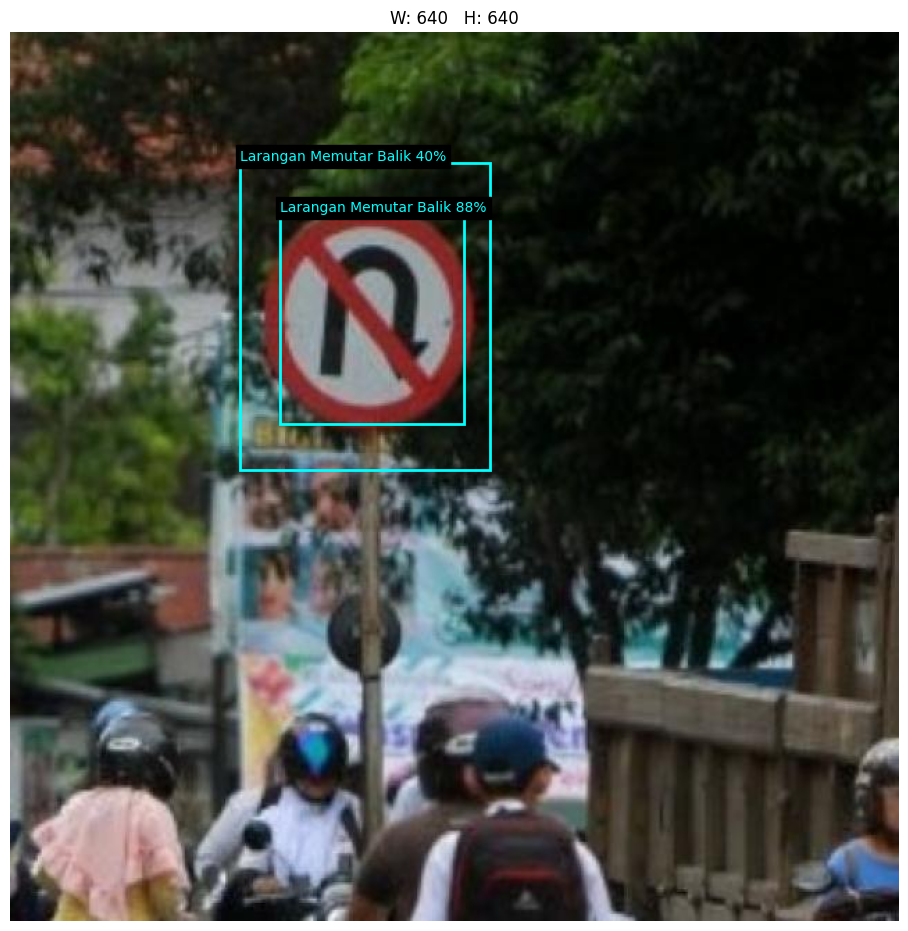

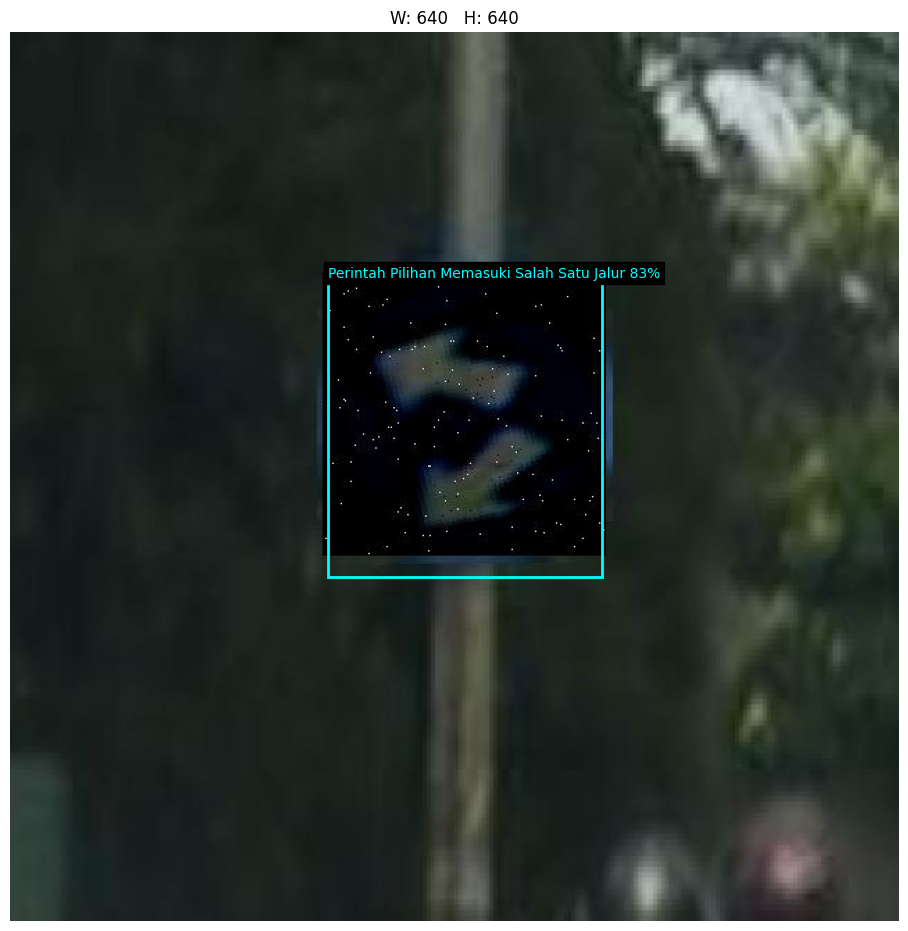

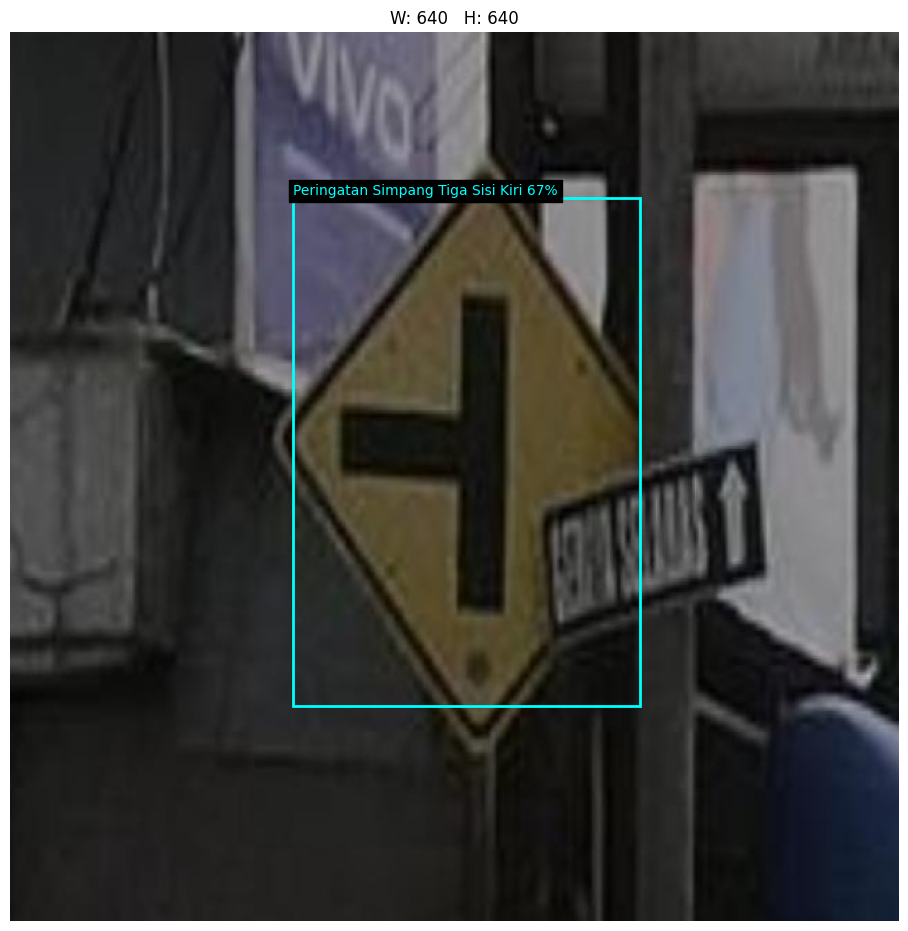

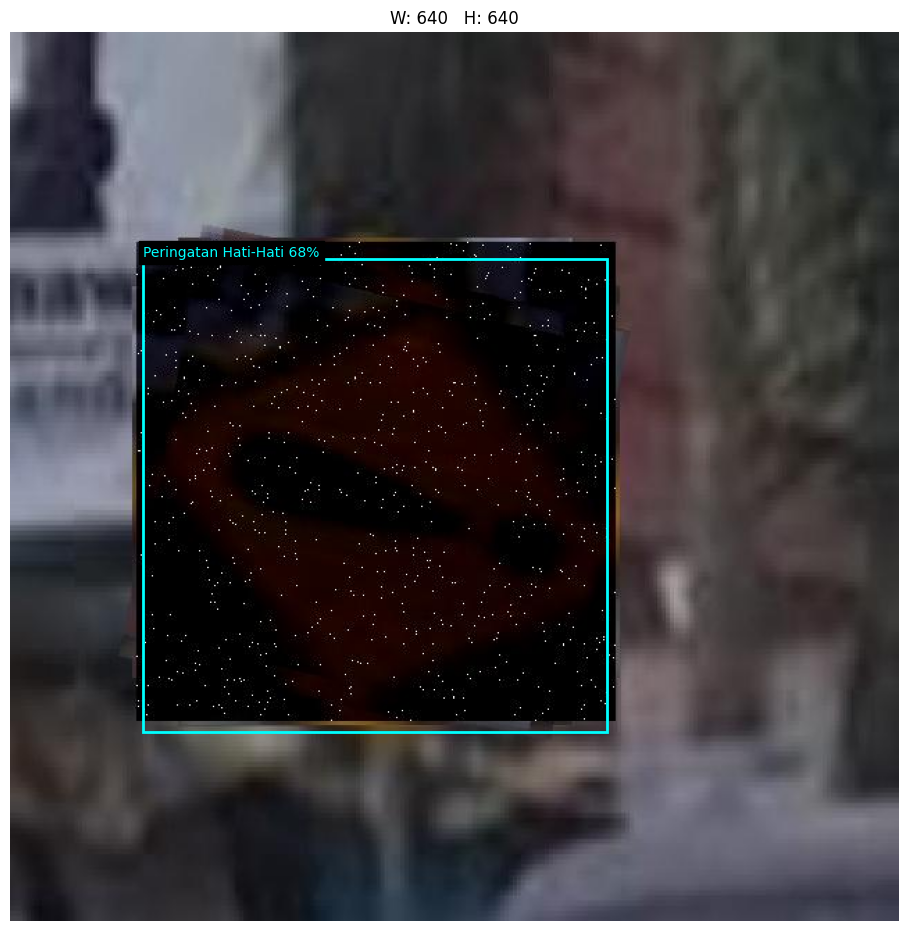

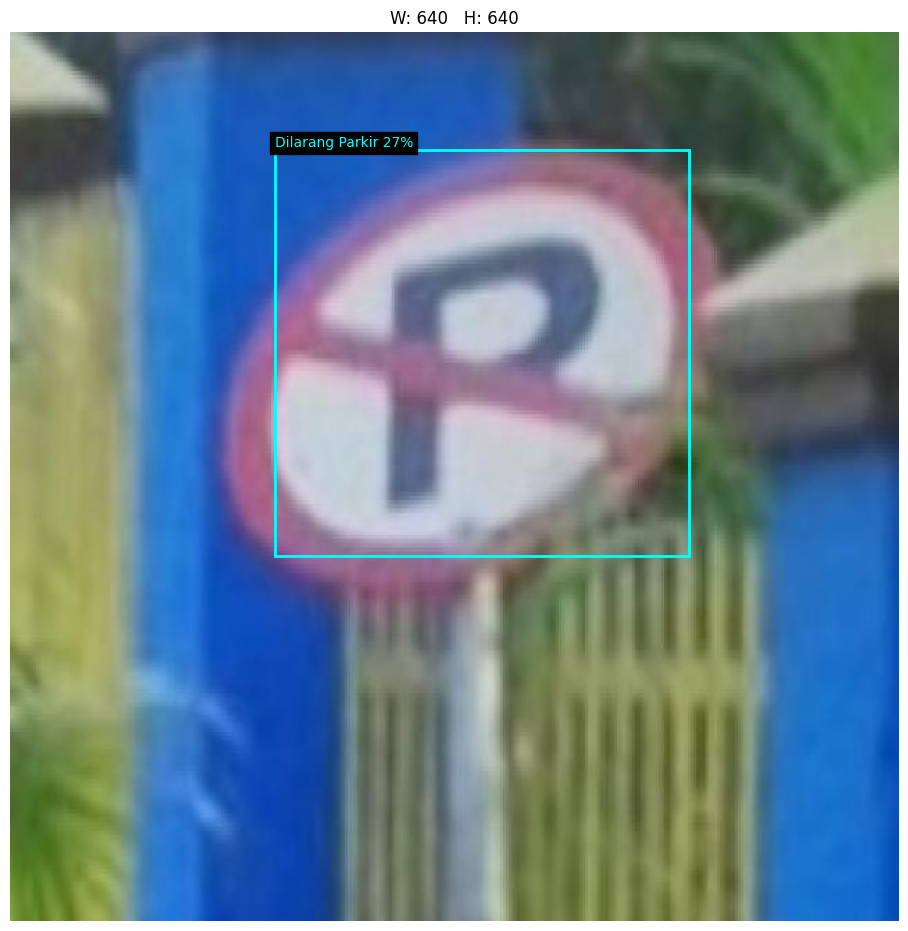

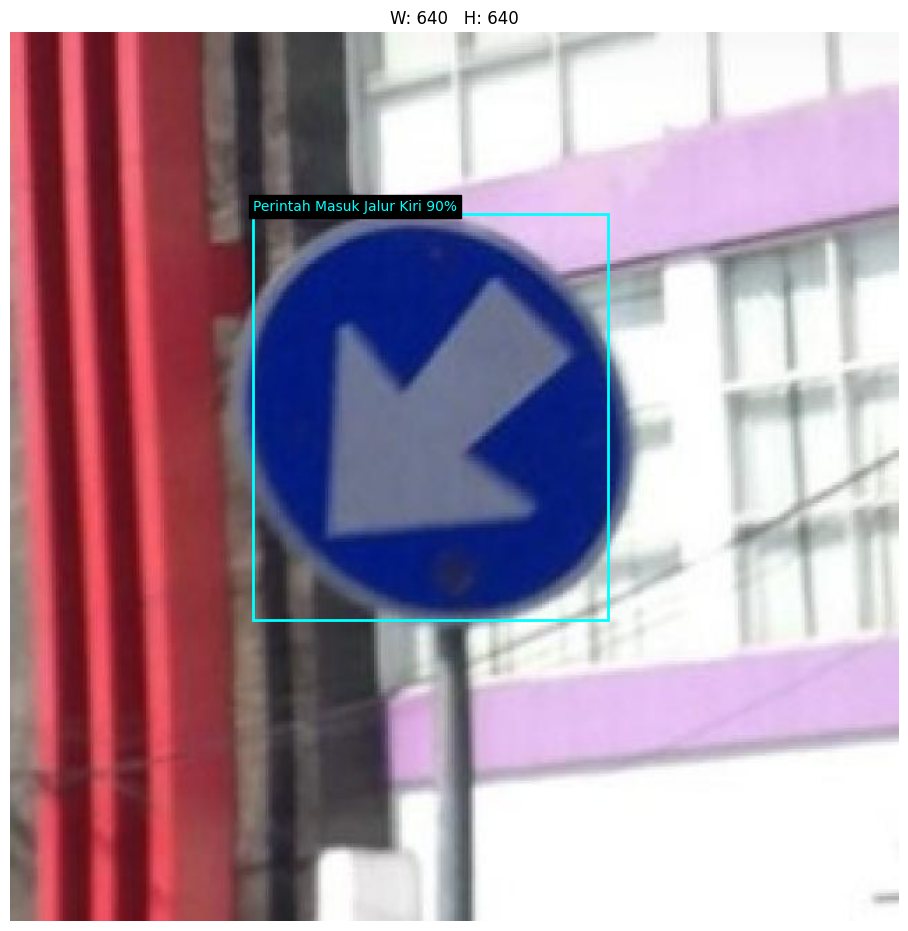

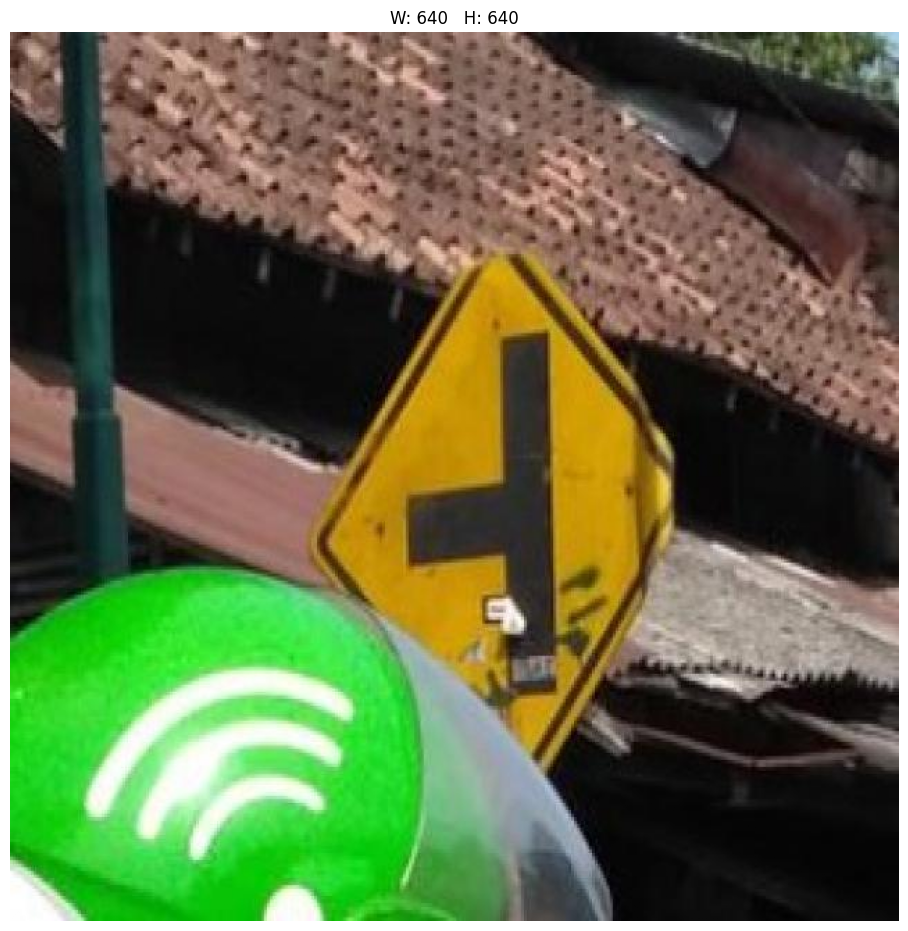

In [26]:
import torch
import torchvision.transforms.functional as F
iters = 10

for i, data in enumerate(d):
    images = data.images
    targets = data.targets

    def preprocess_tensor(img: torch.Tensor):
            # img shape: [C,H,W], dtype float or uint8
            img = F.center_crop(img, [640, 640])   # crop to square
            img = F.resize(img, [640, 640])        # resize to 256x256
            if img.dtype != torch.float32:
                img = img.float() / 255.0          # normalize to [0,1] if needed
            return img

    images = [preprocess_tensor(img) for img in images]
    images = torch.stack(images, dim=0)   # [B,C,256,256]

    with torch.no_grad():
        results, losses = model(images)

    # images' saving names
    save = [os.path.join(output_dir, "{}.jpg".format(tgt["image_id"].item())) for tgt in targets]
    yolo.show(images, results, ds.classes, save)

    if i >= iters - 1:
        break

In [8]:
import os
import json
from collections import defaultdict
import shutil

# === CONFIG ===
json_path = "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/test/_annotations.coco.json"  # path to your COCO json
folder = "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/test"           # path to your folder with JPGs


# === LOAD JSON ===
with open(json_path, "r") as f:
    data = json.load(f)

json_files = [img["file_name"] for img in data["images"]]
json_map = defaultdict(list)
for name in json_files:
    prefix = name.split(".rf.")[0]
    json_map[prefix].append(name)

folder_files = [f for f in os.listdir(folder) if f.endswith(".jpg")]
folder_map = defaultdict(list)
for f in folder_files:
    prefix = f.split(".rf.")[0]
    folder_map[prefix].append(f)

renamed, duplicated, missing = [], [], []

for prefix, targets in json_map.items():
    existing = folder_map.get(prefix, [])
    if not existing:
        print(f"❌ No source file found for prefix: {prefix}")
        missing.extend(targets)
        continue

    # Pick the first available file as source
    source_file = os.path.join(folder, existing[0])

    for i, target in enumerate(targets):
        target_path = os.path.join(folder, target)

        # Skip if already correct
        if os.path.exists(target_path):
            continue

        # Reconfirm that the source still exists
        if not os.path.exists(source_file):
            # It might have been renamed earlier
            possible_sources = [os.path.join(folder, t) for t in targets if os.path.exists(os.path.join(folder, t))]
            if possible_sources:
                source_file = possible_sources[0]
            else:
                print(f"⚠️ All sources missing for {prefix}, skipping {target}")
                missing.append(target)
                continue

        if os.path.basename(source_file) == os.path.basename(target_path):
            print(f"⚠️ Skipping same-name copy: {target}")
            continue

        if i == 0:
            print(f"🔁 Renaming: {os.path.basename(source_file)}  →  {target}")
            os.rename(source_file, target_path)
            source_file = target_path  # Update source after rename
            renamed.append((prefix, target))
        else:
            print(f"📄 Duplicating: {os.path.basename(source_file)}  →  {target}")
            shutil.copy2(source_file, target_path)
            duplicated.append(target)

print(f"\n✅ Done! Renamed {len(renamed)} | Duplicated {len(duplicated)} | Missing {len(missing)}")


✅ Done! Renamed 0 | Duplicated 0 | Missing 0


In [13]:
import os
import json

# === CONFIGURATION ===
folder = "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/train2017"         # path to your image folder
json_path = "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/annotations/instances_train2017.json"

# === LOAD JSON ===
with open(json_path, "r") as f:
    data = json.load(f)

# Get filenames referenced in JSON
json_files = {img["file_name"] for img in data["images"]}

# Get all JPG files in folder
folder_files = [f for f in os.listdir(folder) if f.endswith(".jpg")]

# Identify extra files not in JSON
extra_files = [f for f in folder_files if f not in json_files]

print(f"Total images in JSON: {len(json_files)}")
print(f"Total images in folder: {len(folder_files)}")
print(f"⚠️ Missing in JSON (exist in folder but not referenced): {len(extra_files)}")

for f in extra_files[:20]:
    print("   ", f)
if len(extra_files) > 20:
    print("   ...")

# === DELETE CONFIRMATION ===
confirm = input("\nType 'yes' to DELETE these files permanently: ").strip().lower()
if confirm == "yes":
    for f in extra_files:
        os.remove(os.path.join(folder, f))
    print(f"✅ Deleted {len(extra_files)} unreferenced files.")
else:
    print("❌ Deletion cancelled.")


Total images in JSON: 3081
Total images in folder: 3081
⚠️ Missing in JSON (exist in folder but not referenced): 0


KeyboardInterrupt: Interrupted by user

In [15]:
import json
import os

# === CONFIG ===
json_path = "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/annotations/instances_train2017.json"
image_dir = "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/train2017"

# === LOAD JSON ===
with open(json_path, "r") as f:
    data = json.load(f)

# Extract image filenames from JSON
json_images = {img["file_name"] for img in data["images"]}

# Extract filenames (without subdirs) from the image folder
folder_images = {f for f in os.listdir(image_dir) if f.lower().endswith(".jpg")}

# Compare sets
missing_in_folder = sorted(list(json_images - folder_images))
missing_in_json = sorted(list(folder_images - json_images))

# === REPORT ===
print(f"Total images in JSON: {len(json_images)}")
print(f"Total images in folder: {len(folder_images)}\n")

print(f"❌ Missing in folder (referenced but not found): {len(missing_in_folder)}")
for name in missing_in_folder[:10]:
    print("  ", name)
if len(missing_in_folder) > 10:
    print("  ...")

print(f"\n⚠️ Missing in JSON (exist in folder but not referenced): {len(missing_in_json)}")
for name in missing_in_json[:10]:
    print("  ", name)
if len(missing_in_json) > 10:
    print("  ...")


Total images in JSON: 3081
Total images in folder: 3081

❌ Missing in folder (referenced but not found): 0

⚠️ Missing in JSON (exist in folder but not referenced): 0


In [18]:
import train
import os
import sys
import subprocess
import argparse

def mainfunc():
    root = "."
    dataset = "coco"
    batch_size = 4
    print_freq = 100
    lr = 0.01
    epochs = 10
    period = 10
    img_size1, img_size2 = 640, 640
    ckpt_file = f"yolov5s_{dataset}.pth"
    iters = -1

    if dataset == "voc":
        data_dir = os.path.join(root, "input/data/voc2012/VOCdevkit/VOC2012/")
    elif dataset == "coco":
        data_dir = os.path.join(root, "Traffic-Sign-Indonesia-2")

    train_py = os.path.join(root, "train.py")
    args = [
        # sys.executable, train_py,
        "--use-cuda",
        "--epochs", str(epochs),
        "--period", str(period),
        "--batch-size", str(batch_size),
        "--lr", str(lr),
        "--img-sizes", str(img_size1), str(img_size2),
        "--dataset", dataset,
        "--data-dir", data_dir,
        "--iters", str(iters),
        "--root", root,
        "--mosaic",
        "--dali",
        "--ckpt-path", os.path.join(root, "ckpts", ckpt_file),
        "--print-freq", str(print_freq),
    ]

    parser = argparse.ArgumentParser()
    parser.add_argument("--use-cuda", action="store_true") # whether use the GPU

    parser.add_argument("--dataset", default="coco") # style of dataset, choice: ["coco", "voc"]
    parser.add_argument("--data-dir", default="/data/coco2017") # root directory of the dataset
    parser.add_argument("--dali", action="store_true") # NVIDIA's DataLoader, faster but without random affine
    parser.add_argument("--ckpt-path") # basic checkpoint path
    parser.add_argument("--results") # path where to save the evaluation results

    # you may not train the model for 273 epochs once, and want to split it into several tasks.
    # set epochs={the target epoch of each training task}
    parser.add_argument("--epochs", type=int, default=1)

    # total epochs. iterations=500000, true batch size=64, so total epochs=272.93
    parser.add_argument("--period", type=int, default=273)
    parser.add_argument("--batch-size", type=int, default=64)
    parser.add_argument("--iters", type=int, default=-1) # max iterations per epoch, -1 denotes an entire epoch

    parser.add_argument("--seed", type=int, default=3) # random seed
    parser.add_argument("--model-size", default="small") # choice: ["small", "medium", "large", "extreme"]
    parser.add_argument('--img-sizes', nargs="+", type=int, default=[320, 416]) # range of input images' max_size during training
    parser.add_argument("--lr", type=float, default=0.01)
    parser.add_argument("--momentum", type=float, default=0.937)
    parser.add_argument("--weight-decay", type=float, default=0.0005)

    parser.add_argument("--mosaic", action="store_true") # mosaic data augmentaion, increasing ~2% AP, a little slow
    parser.add_argument("--print-freq", type=int, default=100) # frequency of printing losses during training
    parser.add_argument("--world-size", type=int, default=1) # total number of processes
    parser.add_argument("--dist-url", default="env://") # distributed initial method

    parser.add_argument("--root") # gpu cloud platform special
    args = parser.parse_args(args)

    if args.ckpt_path is None:
      args.ckpt_path = "./checkpoint.pth"
    if args.results is None:
      args.results = os.path.join(os.path.dirname(args.ckpt_path), "results.json")

    train.main(args)

    # log file
    # log_path = os.path.join(root, "data/logs/log.txt")
    # with open(log_path, "w") as log_file:
    #     process = subprocess.Popen(args, stdout=log_file, stderr=log_file)
    #     process.wait()

    # print(f"Training finished. Logs are saved to {log_path}")

mainfunc()


Not using distributed mode
Wed Oct 22 16:00:54 2025
cuda: True
available GPU(s): 1
0: {'name': 'Tesla T4', 'capability': [7, 5], 'total_momory': 14.74, 'sm_count': 40}

device: cuda
Automatic mixed precision (AMP) is enabled!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Namespace(use_cuda=True, dataset='coco', data_dir='./Traffic-Sign-Indonesia-2', dali=True, ckpt_path='./ckpts/yolov5s_coco.pth', results='./ckpts/results.json', epochs=10, period=10, batch_size=4, iters=-1, seed=3, model_size='small', img_sizes=[640, 640], lr=0.01, momentum=0.937, weight_decay=0.0005, mosaic=True, print_freq=100, world_size=1, dist_url='env://', root='.', distributed=False, gpu=0, amp=True, num_workers=1, warmup_iters=2310)
Optimizer param groups: 38 conv_weights, 74 biases, 81 others

already trained: 0 epochs; to 10 epochs

epoch: 1
lr_epoch: 0.0100, factor: 1.0000
0	 0.087	0.151	0.

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


iter: 120.9, total: 113.3, model: 112.6
all gather: 0.0s
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.02s).
Accumulating evaluation results...
DONE (t=0.06s).
accumulate: 0.1s
training: 169.61 s, evaluation: 9.04 s
{'bbox AP': 2.7}

epoch: 2
lr_epoch: 0.0098, factor: 0.9780
800	 0.107	0.016	0.265
900	 0.033	0.021	0.084
1000	 0.033	0.016	0.094
1100	 0.047	0.018	0.053
1200	 0.048	0.021	0.079
1300	 0.054	0.021	0.163
1400	 0.035	0.019	0.106
1500	 0.034	0.021	0.098
iter: 219.1, total: 217.7, model: 186.5, backward: 26.9, optimizer: 2.6, ema: 31.1
iter: 59.7, total: 50.8, model: 49.8
all gather: 0.0s
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.19s).
Accumulating evaluation results...
DONE (t=0.14s).
accumulate: 0.3s
training: 168.70 s, evaluation: 4.80 s
{'bbox AP': 10.2}

e

In [ ]:
!ls "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/train2017/larangan-belok-kanan-64-_jpg.rf.ccd6e78efb394287ed296dfeb100d9a7.jpg"

In [ ]:
!cd "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/train2017" && find *.jpg | wc -l

In [ ]:
# import argparse
# import os
# import time
# import torch
# import yolo


# def main(args):
#     device = torch.device("cuda" if torch.cuda.is_available() and args.use_cuda else "cpu")
#     cuda = device.type == "cuda"
#     if cuda: yolo.get_gpu_prop(show=True)
#     print("\ndevice: {}".format(device))

#     args.amp = False
#     if cuda and torch.__version__ >= "1.6.0":
#         capability = torch.cuda.get_device_capability()[0]
#         if capability >= 7: # 7 refers to RTX series GPUs
#             args.amp = True
#             print("Automatic mixed precision (AMP) is enabled!")

#     # ---------------------- prepare data loader ------------------------------- #

#     DALI = cuda & yolo.DALI & (args.dataset == "coco")

#     if DALI:
#         print("Nvidia DALI is utilized!")
#         d_test = yolo.DALICOCODataLoader(
#             args.file_root, args.ann_file, args.batch_size, collate_fn=yolo.collate_wrapper)
#     else:
#         dataset_test = yolo.datasets(args.dataset, args.file_root, args.ann_file, train=True) # set train=True for eval
#         sampler_test = torch.utils.data.SequentialSampler(dataset_test)

#         batch_sampler_test = yolo.GroupedBatchSampler(
#             sampler_test, dataset_test.aspect_ratios, args.batch_size)

#         args.num_workers = min(os.cpu_count() // 2, 8, args.batch_size if args.batch_size > 1 else 0)
#         data_loader_test = torch.utils.data.DataLoader(
#             dataset_test, batch_sampler=batch_sampler_test, num_workers=args.num_workers,
#             collate_fn=yolo.collate_wrapper, pin_memory=cuda)

#         d_test = yolo.DataPrefetcher(data_loader_test) if cuda else data_loader_test

#     # -------------------------------------------------------------------------- #

#     yolo.setup_seed(3)

#     model_sizes = {"small": (0.33, 0.5), "medium": (0.67, 0.75), "large": (1, 1), "extreme": (1.33, 1.25)}
#     num_classes = len(d_test.dataset.classes)
#     model = yolo.YOLOv5(num_classes, model_sizes[args.model_size], **args.kwargs).to(device)
#     model.head.eval_with_loss = args.eval_with_loss

#     checkpoint = torch.load(args.ckpt_path, map_location=device)
#     if "ema" in checkpoint:
#         model.load_state_dict(checkpoint["ema"][0])
#         print(checkpoint["eval_info"])
#     else:
#         model.load_state_dict(checkpoint)

#     model.fuse()
#     print("evaluating...")
#     B = time.time()
#     eval_output, iter_eval = yolo.evaluate(model, d_test, device, args, evaluation=args.evaluation)
#     B = time.time() - B
#     print(eval_output)
#     print("\ntotal time of this evaluation: {:.2f} s, speed: {:.2f} FPS".format(B, args.batch_size / iter_eval))


# if __name__ == "__main__":
#     parser = argparse.ArgumentParser()
#     args = parser.parse_args([]) # [] is needed when using Jupyter Notebook.

#     args.use_cuda = True

#     args.dataset = "coco"
#     args.file_root = "Traffic-Sign-Indonesia-3/train2017"
#     args.ann_file = "Traffic-Sign-Indonesia-3/train2017/_annotations.coco.json"
#     args.ckpt_path = "ckpts/yolov5s_coco-3.pth"
#     args.results = os.path.join(os.path.dirname(args.ckpt_path), "results.json")

#     args.batch_size = 32
#     args.iters = -1

#     args.model_size = "small"
#     args.kwargs = {"img_sizes": 640, "score_thresh": 0.1, "detections": 100} # mAP 34.6 FPS 451
#     #args.kwargs = {"img_sizes": 672, "score_thresh": 0.001, "detections": 300} # mAP 36.1. take more(2x-4x) time in total
#     args.evaluation = True
#     args.eval_with_loss = False

#     main(args)



In [ ]:
# import yolo
# import torch
# import cv2
# import os
# import matplotlib.pyplot as plt

# # ==== 1. CONFIG ====
# ckpt_path = "ckpts/yolov5s_coco-3.pth"   # path to .pth file
# image_dir = "Traffic-Sign-Indonesia-3/val2017"   # folder with test images
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # ==== 2. LOAD MODEL ====
# model = yolo.YOLOv5(22, img_sizes=(640, 640), score_thresh=0.01) # adjust num_classes if custom dataset
# checkpoint = torch.load(ckpt_path, map_location=device)
# model.load_state_dict(checkpoint['model'])
# model.to(device).eval()

# # Your class names (example placeholder)
# classes = (
#   "Dilarang Berhenti",
#   "Dilarang Masuk",
#   "Dilarang Parkir",
#   "Lampu Hijau",
#   "Lampu Kuning",
#   "Lampu Merah",
#   "Larangan Belok Kanan",
#   "Larangan Belok Kiri",
#   "Larangan Berjalan Terus Wajib Berhenti Sesaat",
#   "Larangan Memutar Balik",
#   "Peringatan Alat Pemberi Isyarat Lalu Lintas",
#   "Peringatan Banyak Pejalan Kaki Menggunakan Zebra Cross",
#   "Peringatan Hati-Hati",
#   "Peringatan Pintu Perlintasan Kereta Api",
#   "Peringatan Simpang Tiga Sisi Kiri",
#   "Perintah Masuk Jalur Kiri",
#   "Perintah Pilihan Memasuki Salah Satu Jalur",
#   "Petunjuk Area Parkir",
#   "Petunjuk Lokasi Pemberhentian Bus",
#   "Petunjuk Lokasi Putar Balik",
#   "Petunjuk Penyeberangan Pejalan Kaki")

# # Image preprocessing
# transform = transforms.Compose([
#     transforms.Resize((640, 640)),
#     transforms.ToTensor(),
# ])

# def predict_and_visualize(img_path, conf_thresh=0.01):
#     # Load and prepare image
#     img = Image.open(img_path).convert("RGB")
#     img_tensor = transforms.ToTensor()(img)  # shape [C,H,W]

#     # Forward pass (model handles resize internally)
#     with torch.no_grad():
#         results, losses = model([img_tensor.to(device)])  # model expects list of tensors

#     # results is a list of dicts (one per image)
#     preds = results[0]

#     # Filter by confidence
#     conf_mask = preds["scores"] > conf_thresh
#     preds = {k: v[conf_mask].cpu() for k, v in preds.items()}

#     # Visualize using provided function

#     print(f"RESULTS TYPE: {type(results)}")
#     if isinstance(results, list):
#         print(f"LIST LENGTH: {len(results)}")
#         if len(results) > 0:
#             print(f"[0] keys: {results[0].keys()}")
#             for k, v in results[0].items():
#                 print(f"  {k}: {v.shape if isinstance(v, torch.Tensor) else type(v)}")
#     else:
#         print(results)
#     yolo.show(
#         img_tensor,  # image as tensor [3,H,W]
#         preds,       # dict with boxes, labels, scores
#         classes,     # tuple of class names
#         save=""      # no save, just show
#     )
# import glob

# for img_path in glob.glob(image_dir + "/*.jpg")[:5]:
#     predict_and_visualize(img_path)
